<a href="https://colab.research.google.com/github/KDitsa/Document-Parsing/blob/Feature%2FDocParseVLM/Microsoft_Florence_VLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q transformers bitsandbytes accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 105.0 MB/s eta 0:00:00


In [3]:
import torch
from transformers import AutoModelForCausalLM, AutoProcessor

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model_id = 'microsoft/Florence-2-large'

model = AutoModelForCausalLM.from_pretrained(model_id, trust_remote_code=True,load_in_4bit=True)

processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)

print("Model and processor loaded successfully!")

Using device: cuda


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

configuration_florence2.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-large:
- configuration_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-large:
- processing_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_config.json:   0%|          | 0.00/34.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model and processor loaded successfully!


Please select the document image from your desktop...


Saving Invoice sample.jpeg to Invoice sample.jpeg

Successfully uploaded file: "Invoice sample.jpeg"

Displaying your uploaded image:


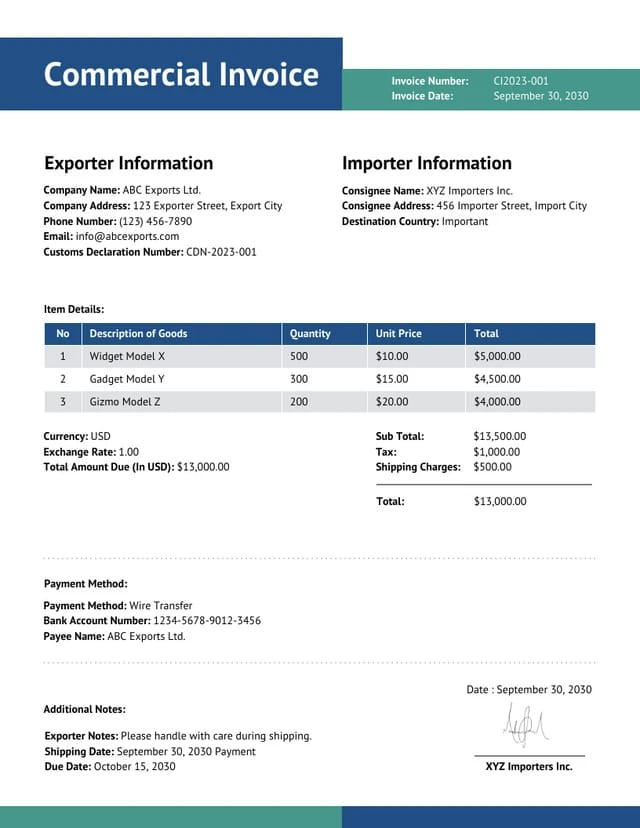

In [4]:
from google.colab import files
from PIL import Image
from io import BytesIO

print("Please select the document image from your desktop...")
uploaded = files.upload()

if len(uploaded) == 0:
  print("\nNo file was selected. Please run the cell again to upload an image.")
else:
  filename = list(uploaded.keys())[0]
  print(f'\nSuccessfully uploaded file: "{filename}"')
  image_bytes = uploaded[filename]
  image = Image.open(BytesIO(image_bytes))
  print("\nDisplaying your uploaded image:")
  display(image)

In [5]:
def run_florence_2(image, task_prompt, text_input=None):
    """
    Runs the Florence-2 model for a given image and task prompt.
    This version includes a fix for the dtype mismatch error with quantized models.

    Args:
        image (PIL.Image.Image): The input image.
        task_prompt (str): The prompt defining the task for the model.
        text_input (str, optional): Additional text input for tasks like VQA.

    Returns:
        dict: The parsed output from the model.
    """
    if text_input is None:
        prompt = task_prompt
    else:
        prompt = task_prompt + text_input


    inputs = processor(text=prompt, images=image, return_tensors="pt")


    model_dtype = model.dtype
    inputs["pixel_values"] = inputs["pixel_values"].to(device, dtype=model_dtype)
    inputs["input_ids"] = inputs["input_ids"].to(device)
    inputs["attention_mask"] = inputs["attention_mask"].to(device)

    generated_ids = model.generate(
        input_ids=inputs["input_ids"],
        pixel_values=inputs["pixel_values"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=1024,
        num_beams=3,
        do_sample=False
    )


    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]


    parsed_answer = processor.post_process_generation(
        generated_text,
        task=task_prompt,
        image_size=(image.width, image.height)
    )

    return parsed_answer

In [6]:
if 'image' not in locals():
    print("Please run Step 3 first to upload an image.")
else:
    print("--- Document Visual Question Answering (VQA) ---")

    question1 = "What is written in the document?"
    answer1 = run_florence_2(image, task_prompt=question1)
    print(f"Question: {question1}")
    print(f"Answer: {answer1[question1]}")

    print("\n" + "-"*20 + "\n")



--- Document Visual Question Answering (VQA) ---


/usr/local/lib/python3.11/dist-packages/bitsandbytes/nn/modules.py:457: UserWarning: Input type into Linear4bit is torch.float16, but bnb_4bit_compute_dtype=torch.float32 (default). This will lead to slow inference or training speed.
  warnings.warn(


Question: What is written in the document?
Answer: Commercial Invoice
Invoice Number:
(C)2023-001
Invoice Date:
September 30, 2030
Exporter Information
Importer Information
Company Name: ABC Exports Ltd.
Consignee Name: XYZ Importers Inc.
Company Address: 123 Exporter Street, Export City
Consignee Name: Xyz Impoppers Inc. The
Phone Number: (123) 556-7890
Consigninge Address: 456 Importer Street, Import City
Email: info@abcexports.com
Destination Country: Important
Customs Declaration Number: CDN-2023.001
Item Details:
No
Description of Goods
Quantity
Unit Price
Total
1
Description Of Goods
Widgets Model X
500
$10.00
$5,000,00
2
Gadget Model Y
300
$15.00.
$4,500.00,
3
Gizmo Model Z
200
$20.00:
$24,000.00-
$2
$40,000:00
Currency: USD
Sub Total:
Exchange Rate: 1.0.0
$13,500,000
Total Amount Due (In USD): $13,000-00
Tax:
Shipping Charges:
1,000 00
$500.0,00-0
Total:
Payment Method:
Transaction Method: Wire Transfer
Bank Account Number: 1234-5678-9078-9012-3456
Payee Name : ABC Exporters Lt